# Conformal Good-Turing Classification+ (CGTC+) - Quick Start Demo

This notebook demonstrates **CGTC+**, the revised method from the paper: Conformal Good-Turing Classification with a **plug-in missing-mass budget allocation** and a **cross-validated power-weight parameter $\beta$**.

## What does CGTC+ add over CGTC?

Original CGTC tunes the error-budget split $(\alpha_{\mathrm{class}}, \alpha_{\mathrm{unseen}}, \alpha_{\mathrm{seen}})$ by a direct grid search. CGTC+ replaces the grid search with a data-driven rule built on the Good-Turing missing-mass estimate $\hat{\mu} = (1 + M_1)/(1 + n)$:

1. **Cap**: $\alpha_{\mathrm{unseen}} = \min(\mathrm{cap}, \hat{\mu})$, so we never spend more unseen-label budget than the estimated probability of encountering a new class.
2. **Reallocation**: $\alpha_{\mathrm{class}} = (\alpha - \alpha_{\mathrm{seen}} - \alpha_{\mathrm{unseen}})/(1 - \hat{\mu})$, so the surplus is returned to the classification budget, inflated by $1/(1 - \hat{\mu})$.

Only two hyperparameters (the cap and $\alpha_{\mathrm{seen}}$) are cross-validated; the realized allocation is then derived from the data. In addition, the power weights used to combine the seen-label p-values are selected by cross-validation instead of being fixed.

The original CGTC method, which now appears in the appendix of the paper, is demonstrated in `CGTC_Demo.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from sklearn.neighbors import LocalOutlierFactor
import sys
import os

# Add paths to custom modules
sys.path.insert(0, os.path.abspath('third_party'))
sys.path.insert(0, 'cgtc/')

# Import ARC utilities
from arc import black_boxes

# Import the CGTC+ plug-in allocation and beta selection
from alpha_tune_plugin import tune_plugin_allocation_cv, compute_plugin_allocation
from testing import psi0_gt, select_beta_cv

# Import CGTC methods
from conformal_methods import (
    evaluate_prediction_sets,
    finalize_prediction_sets,
    get_preliminary_sets_naive,
    get_preliminary_sets_benchmark,
    get_preliminary_sets_Bernoulli
)
from distributions_x import ShiftedNormal
from distributions_y import DirichletProcess

# Set random seed for reproducibility
np.random.seed(42)

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Data generation

Labels are drawn from a Dirichlet Process (DP) with concentration parameter $\theta$ (larger $\theta$ means more label diversity, hence more unseen labels at test time), and features are Gaussian around a label-specific center. We use the paper's main synthetic configuration: $\theta = 1000$, three features, $\sigma = 10^{-4}$, $n_{\mathrm{ref}} = 2000$ reference points and $n_{\mathrm{test}} = 1000$ test points.

In [2]:
# Data generation parameters (the paper's main synthetic configuration)
theta = 1000      # DP concentration parameter (controls label diversity)
num_features = 3  # Feature dimensionality
sigma = 1e-4      # Variance of feature distribution around labels

# Sample sizes
n_ref = 2000   # Reference data (training + calibration)
n_test = 1000  # Test data

# Create data distribution
label_dist = DirichletProcess(theta=theta)
feature_dist = ShiftedNormal(num_features, sigma)

class DataDistribution:
    def __init__(self, label_dist, feature_dist):
        self.label_dist = label_dist
        self.feature_dist = feature_dist

    def sample(self, n, random_state=None):
        Y = self.label_dist.sample(n, random_state=random_state)
        X = self.feature_dist.sample(Y, random_state=random_state)
        return X, Y

data_dist = DataDistribution(label_dist, feature_dist)

# Generate data
X_all, Y_all = data_dist.sample(n_ref + n_test, random_state=42)

# Split into reference and test
X_ref, Y_ref = X_all[:n_ref], Y_all[:n_ref]
X_test, Y_test = X_all[n_ref:], Y_all[n_ref:]

print(f"Reference data: {len(Y_ref)} samples")
print(f"Test data: {len(Y_test)} samples")
print(f"\nUnique labels in reference: {len(np.unique(Y_ref))}")
print(f"Unique labels in test: {len(np.unique(Y_test))}")

Reference data: 2000 samples
Test data: 1000 samples

Unique labels in reference: 1105
Unique labels in test: 692


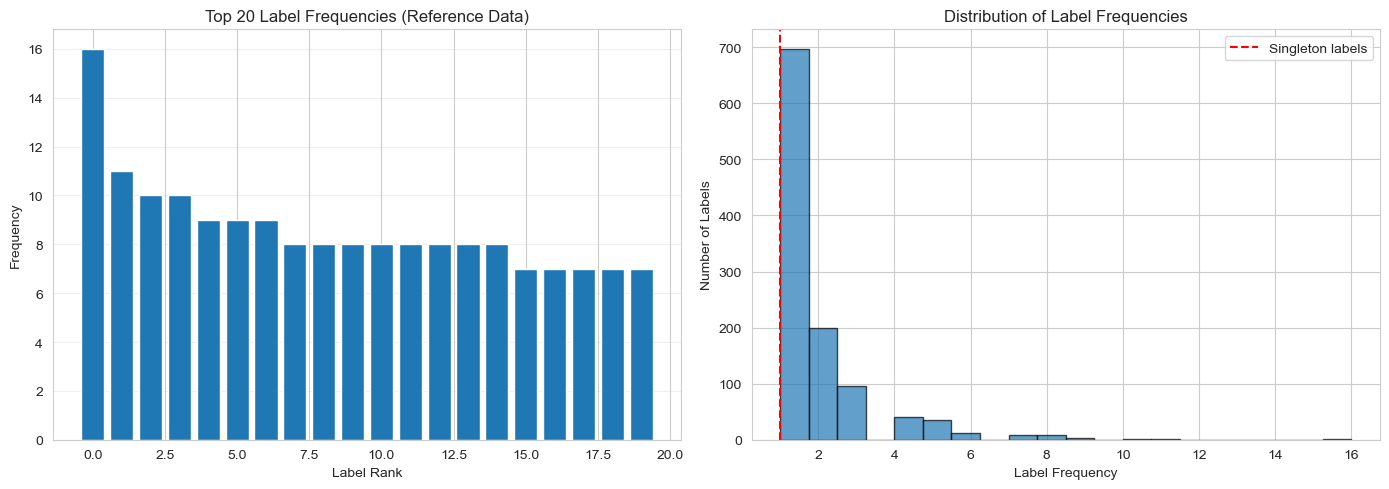

Labels appearing only once: 697 (63.1%)
Labels appearing <=5 times: 1069 (96.7%)
Most common label frequency: 16
Median label frequency: 1.0


In [3]:
# Count label frequencies
unique_labels, counts = np.unique(Y_ref, return_counts=True)
sorted_idx = np.argsort(counts)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of label frequencies (top 20)
top_n = min(20, len(unique_labels))
axes[0].bar(range(top_n), counts[sorted_idx[:top_n]])
axes[0].set_xlabel('Label Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Top {top_n} Label Frequencies (Reference Data)')
axes[0].grid(axis='y', alpha=0.3)

# Distribution of frequencies
axes[1].hist(counts, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Label Frequency')
axes[1].set_ylabel('Number of Labels')
axes[1].set_title('Distribution of Label Frequencies')
axes[1].axvline(x=1, color='red', linestyle='--', label='Singleton labels')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Labels appearing only once: {np.sum(counts == 1)} ({np.mean(counts == 1):.1%})")
print(f"Labels appearing <=5 times: {np.sum(counts <= 5)} ({np.mean(counts <= 5):.1%})")
print(f"Most common label frequency: {counts.max()}")
print(f"Median label frequency: {np.median(counts):.1f}")

## The missing mass and its Good-Turing estimate

The missing mass is the total probability of labels that do not appear in the reference sample. CGTC+ estimates it with the Good-Turing plug-in
$$\hat{\mu} = \frac{1 + M_1}{1 + n},$$
where $M_1$ is the number of labels observed exactly once. Note that $\hat{\mu}$ is a different quantity from the singleton proportion $M_1/n$, which the selective splitting rule below uses for a different purpose.

The estimate plays two roles in CGTC+: it caps the unseen-label budget $\alpha_{\mathrm{unseen}}$, and it inflates the classification budget $\alpha_{\mathrm{class}}$ by the factor $1/(1 - \hat{\mu})$.

In [4]:
# Plug-in Good-Turing missing-mass estimate
mu_hat_plugin = psi0_gt(Y_ref)

# Related, but distinct, quantities
M1 = np.sum(counts == 1)
singleton_prop = M1 / len(Y_ref)

seen_labels = np.unique(Y_ref)
num_unique_labels = len(seen_labels)
unseen_mask = ~np.isin(Y_test, seen_labels)
prop_unseen = unseen_mask.mean()
num_unseen = np.sum(unseen_mask)

print(f"Number of singleton labels M1: {M1}")
print(f"Singleton proportion M1/n: {singleton_prop:.4f}")
print(f"Plug-in missing-mass estimate mu_hat = (1+M1)/(1+n): {mu_hat_plugin:.4f}")
print(f"Realized proportion of unseen labels in the test set: {prop_unseen:.4f} "
      f"({num_unseen}/{len(Y_test)} points)")

Number of singleton labels M1: 697
Singleton proportion M1/n: 0.3485
Plug-in missing-mass estimate mu_hat = (1+M1)/(1+n): 0.3488
Realized proportion of unseen labels in the test set: 0.3290 (329/1000 points)


## Helpers for selective (Bernoulli) splitting

Selective splitting sends each data point to the calibration set with a probability that depends on its label frequency: never for frequency-0 or frequency-1 labels, and with an adjusted probability otherwise, chosen so that the expected calibration size still matches `calib_size` despite the excluded singletons.

In [5]:

def calculate_freq_one_proportion(Y_ref):
    """
    Calculate the proportion of data points that have frequency-1 labels.
    """
    unique_labels, counts = np.unique(Y_ref, return_counts=True)
    freq_one_labels = unique_labels[counts == 1]
    freq_one_mask = np.isin(Y_ref, freq_one_labels)
    freq_one_prop = np.mean(freq_one_mask)
    return freq_one_prop


def calib_prob_real(frequency, exp_prop=0.1, freq_one_prop=None):
    """
    Given a positive integer 'frequency' representing the frequency count of a label,
    returns the probability of that label being selected into the calibration set.

    Args:
        frequency: Frequency count of the label
        exp_prop: Base expected proportion (calib_size)
        freq_one_prop: Proportion of data points with frequency-1 labels
    """
    if frequency == 0:
        return 0.0
    elif frequency == 1:
        return 0.0
    else:
        # If freq_one_prop is provided, adjust the probability to maintain expected calibration size
        if freq_one_prop is not None and freq_one_prop < 1.0:
            # Adjusted probability to compensate for excluded frequency-1 labels
            # We need: adjusted_prob * (1 - freq_one_prop) = exp_prop
            adjusted_prob = exp_prop / (1 - freq_one_prop)
            # Cap at 1.0 to ensure it's a valid probability
            prob_calib = min(adjusted_prob, 1.0)
        else:
            # Fallback to base proportion if no adjustment needed
            prob_calib = exp_prop
        return prob_calib


## Models

An open-set $k$-NN classifier (from the ARC package) provides the conformity scores, and a Local Outlier Factor one-class classifier supplies the feature-based evidence used by the XGT p-value.

In [6]:
# Open-set classifier (k-NN black box from ARC)
n_neighbors = 5
classifier = black_boxes.OpenSetKNN(
    calibrate=False,
    n_neighbors=n_neighbors,
    weights='distance',
    algorithm='auto',
    n_jobs=-1
)

# One-class classifier for novelty detection (used by the XGT p-values)
occ = LocalOutlierFactor(n_neighbors=1, novelty=True)

print(f"Classifier: k-NN (k={n_neighbors})")
print(f"OCC: Local Outlier Factor")

Classifier: k-NN (k=5)
OCC: Local Outlier Factor


## CGTC+ budget allocation: tune, then deploy

Two steps.

**Tune**: cross-validate the cap on $\alpha_{\mathrm{unseen}}$ and the value of $\alpha_{\mathrm{seen}}$ by minimizing the same loss as the original tuner, $\lambda \cdot \text{(normalized size)} + (1-\lambda) \cdot \text{(joker waste)}$. Within each fold, the realized allocation is derived from that fold's own missing-mass estimate.

**Deploy**: derive the final allocation from the full reference sample via `compute_plugin_allocation`.

The paper's experiments use $K = 10$ folds and a cap grid of size $G = 20$; this demo uses $K = 2$ and $G = 5$ so that the tuning cell finishes in several minutes.

In [7]:
# Conformal prediction parameters (paper's main configuration)
alpha_total = 0.1    # Total error budget (10%)
calib_size = 0.1     # Expected proportion of reference data used for calibration
lambda_weight = 0.5  # Loss weight between normalized size and joker waste
seed = 123

# Selective-splitting rule, adjusted for the excluded singleton labels
freq_one_prop = calculate_freq_one_proportion(Y_ref)
calib_prob_adjusted = partial(calib_prob_real,
                              exp_prop=calib_size,
                              freq_one_prop=freq_one_prop)

# Step 1 (tune): cross-validate the two hyperparameters (cap, alpha_seen)
best_cap, best_alpha_seen, tuning_results = tune_plugin_allocation_cv(
    X_ref, Y_ref,
    alpha_total=alpha_total,
    lambda_weight=lambda_weight,
    n_splits=2,   # paper: 10
    grid_size=5,  # paper: 20
    classifier=classifier,
    occ=occ,
    calibration_probability=calib_prob_adjusted,
    calib_size=calib_size,
    pvalue_method='XGT',
    random_state=seed,
    beta=None,     # optimal weights inside the tuning loop
    splitting_method='random',
    verbose=True
)

# Step 2 (deploy): derive the realized allocation on the full reference sample
alpha_unseen, alpha_seen, alpha_class, mu_hat = compute_plugin_allocation(
    Y_ref, alpha_total, best_cap, best_alpha_seen
)

print(f"\nTuned hyperparameters: cap = {best_cap:.3f}, alpha_seen = {best_alpha_seen:.3f}")
print(f"Plug-in missing-mass estimate: mu_hat = {mu_hat:.4f}")
print(f"\nDeployed allocation (alpha_total = {alpha_total}):")
print(f"  alpha_unseen = min(cap, mu_hat)           = {alpha_unseen:.4f}")
print(f"  alpha_seen                                = {alpha_seen:.4f}")
print(f"  alpha_class  = (remaining) / (1 - mu_hat) = {alpha_class:.4f}")
print(f"\nReallocation factor 1 / (1 - mu_hat) = {1 / (1 - mu_hat):.3f}")
print(f"For contrast, a fixed equal split would use alpha/3 = {alpha_total / 3:.4f} each.")


Plug-in allocation CV (lambda=0.5, K=2, G=5)
alpha_seen candidates: [0.0, 0.01, 0.02, 0.05]
Random split: Size of all data: 1000. Size of calibration set: 100. 
Random split: Size of all data: 1000. Size of calibration set: 100. 
Per-fold plug-in mu_hat in [0.5025, 0.5255]


cap (alpha_seen=0.00):   0%|                                                                   | 0/6 [00:00<?, ?it/s]

Random split: Size of all data: 1000. Size of calibration set: 100. 


cap (alpha_seen=0.00):   0%|                                                                   | 0/6 [00:05<?, ?it/s]

Random split: Size of all data: 1000. Size of calibration set: 100. 


...

Random split: Size of all data: 1000. Size of calibration set: 100. 


cap (alpha_seen=0.05):  67%|███████████████████████████████████████▎                   | 4/6 [00:30<00:11,  5.75s/it]

Random split: Size of all data: 1000. Size of calibration set: 100. 


cap (alpha_seen=0.05): 100%|███████████████████████████████████████████████████████████| 6/6 [00:38<00:00,  6.42s/it]


Best plug-in hyperparameters (minimum loss):
  alpha_unseen_cap = 0.0400
  alpha_seen       = 0.0000
  Average loss     = 0.6134
  Components: NormSize=0.9523, JokerWaste=0.2745
  Average coverage = 0.9530

Tuned hyperparameters: cap = 0.040, alpha_seen = 0.000
Plug-in missing-mass estimate: mu_hat = 0.3488

Deployed allocation (alpha_total = 0.1):
  alpha_unseen = min(cap, mu_hat)           = 0.0400
  alpha_seen                                = 0.0000
  alpha_class  = (remaining) / (1 - mu_hat) = 0.0921

Reallocation factor 1 / (1 - mu_hat) = 1.536
For contrast, a fixed equal split would use alpha/3 = 0.0333 each.


## Selecting the power-weight parameter $\beta$

The p-values for the individual seen-label hypotheses are combined with frequency-based power weights indexed by $\beta$. CGTC+ selects $\beta$ by 5-fold cross-validation over the grid $\{1.0, 1.2, \ldots, 3.0\}$, minimizing the mean truncated p-value; ties are broken toward the default $\beta = 1.6$.

In [8]:
# Candidate grid used in the paper's experiments
betas = np.linspace(1.0, 3.0, 11)

best_beta, best_score = select_beta_cv(X_ref, Y_ref, betas, cv=5, randomized=True)

print(f"\nSelected beta = {best_beta:.2f} (mean truncated p-value {best_score:.4f})")

[CV] Starting beta cross-validation over 11 values using 5-fold...
[CV] Beta = 1.000, Average CV truncated p-value = 0.656404
[CV] Beta = 1.200, Average CV truncated p-value = 0.700734
[CV] Beta = 1.400, Average CV truncated p-value = 0.789806
[CV] Beta = 1.600, Average CV truncated p-value = 0.903326
[CV] Beta = 1.800, Average CV truncated p-value = 0.974352
[CV] Beta = 2.000, Average CV truncated p-value = 0.996095
[CV] Beta = 2.200, Average CV truncated p-value = 0.999750
[CV] Beta = 2.400, Average CV truncated p-value = 1.000000
[CV] Beta = 2.600, Average CV truncated p-value = 1.000000
[CV] Beta = 2.800, Average CV truncated p-value = 1.000000
[CV] Beta = 3.000, Average CV truncated p-value = 1.000000
[CV] Best beta selected: 1.000 with score 0.656404

Selected beta = 1.00 (mean truncated p-value 0.6564)


## Build prediction sets: CGTC+ versus standard split conformal

Four methods, mirroring the paper's main figure: CGTC+ with random or Bernoulli (selective) splitting, and the standard split-conformal benchmarks under the same two splitting schemes.

The CGTC+ arms build preliminary sets at the inflated $\alpha_{\mathrm{class}}$ and then apply the dual Good-Turing test at $(\alpha_{\mathrm{unseen}}, \alpha_{\mathrm{seen}})$ to decide whether to add the joker option `?`. The benchmarks spend the full budget on a single split-conformal set and have no joker.

In [9]:
# The full budget, used by the standard (benchmark) methods
alpha_full = alpha_unseen + alpha_seen + alpha_class

# Method labels follow the paper's figure legends
methods_list = {
    'CGTC+ (random)': get_preliminary_sets_naive,
    'CGTC+ (selective)': get_preliminary_sets_Bernoulli,
    'standard (random)': get_preliminary_sets_benchmark,
    'standard (selective)': get_preliminary_sets_Bernoulli,
}

results_df = pd.DataFrame()

for method_name, method_function in methods_list.items():
    print(f"Begin running {method_name}")
    info = {}  # receives the realized calibration-set size

    if method_name == 'standard (random)':
        # Standard split conformal spends the full budget, no joker test
        decoded_prelim_sets = method_function(
            X_ref, Y_ref, X_test,
            alpha=alpha_full,
            black_box=classifier,
            calib_size=calib_size,
            random_state=seed,
            info=info
        )
    elif method_name == 'standard (selective)':
        decoded_prelim_sets = method_function(
            X_ref, Y_ref, X_test,
            alpha_prime=alpha_full,
            black_box=classifier,
            calibration_probability=calib_prob_adjusted,
            random_state=seed,
            info=info
        )
    elif method_name == 'CGTC+ (selective)':
        # CGTC+ arms use the deployed (already-inflated) alpha_class
        decoded_prelim_sets = method_function(
            X_ref, Y_ref, X_test,
            alpha_prime=alpha_class,
            black_box=classifier,
            calibration_probability=calib_prob_adjusted,
            random_state=seed,
            info=info
        )
    else:
        decoded_prelim_sets = method_function(
            X_ref, Y_ref, X_test,
            alpha_prime=alpha_class,
            black_box=classifier,
            calib_size=calib_size,
            random_state=seed,
            info=info
        )
    print(f"  Realized calibration size: {info.get('n_calib')}")

    if method_name.startswith('standard'):
        # Benchmarks are final as-is (no Good-Turing test)
        new_results = evaluate_prediction_sets(decoded_prelim_sets, Y_test, Y_ref, verbose=False)
        new_results['method'] = method_name
        new_results['pvalue_method'] = '(none)'
        results_df = pd.concat([results_df, new_results])
    else:
        # Apply each conformal Good-Turing p-value and the dual test
        for pvalue_method in ['GT', 'XGT', 'RGT']:
            final_sets = finalize_prediction_sets(
                decoded_prelim_sets,
                X_ref, Y_ref, X_test,
                pvalue_method,
                alpha_unseen, alpha_seen,
                occ=occ,
                random_state=seed,
                beta=best_beta
            )
            new_results = evaluate_prediction_sets(final_sets, Y_test, Y_ref, verbose=False)
            new_results['method'] = method_name
            new_results['pvalue_method'] = pvalue_method
            results_df = pd.concat([results_df, new_results])

results_df = results_df.reset_index(drop=True)
print(f"\nDone: {len(results_df)} result rows")

Begin running CGTC+ (random)
Random split: Size of all data: 2000. Size of calibration set: 200. 
  Realized calibration size: 200
Begin running CGTC+ (selective)
Bernoulli: Size of all data: 2000. Size of calibration set: 197. 
  Alpha: 0.0921
  Calibration scores range: [-0.9078, 0.0748]
  Calibration scores mean: -0.6355, std: 0.1958
  Alpha_max range: [0.0173, 0.9999]
  Alpha_max mean: 0.7276, std: 0.1958
  Number of unique labels: 1105
  Number of calibration points: 197

  Permuted probability statistics (first 5 candidates):
    Candidate 0: sum=201.3354, mean=1.0220, std=0.1987, range=[0.0000, 1.1813], alpha_calib=0.5308
    Candidate 1: sum=170.4321, mean=0.8651, std=0.1682, range=[0.0000, 1.0000], alpha_calib=0.5306
    Candidate 2: sum=170.4321, mean=0.8651, std=0.1682, range=[0.0000, 1.0000], alpha_calib=0.5306
    Candidate 3: sum=201.3354, mean=1.0220, std=0.1987, range=[0.0000, 1.1813], alpha_calib=0.5308
    Candidate 4: sum=170.4321, mean=0.8651, std=0.1682, range=[0.0

## Results

Conventions used in the paper: `Size` never counts the joker (`Size (?)` includes it and is kept for reference only), and `Coverage (?)` credits the joker exactly when the true label is genuinely unseen. The paper's headline results use the XGT p-value.

Expect the CGTC+ rows to sit near the nominal coverage $1 - \alpha = 0.9$, while the standard benchmarks fall short of it in the presence of unseen labels.

In [10]:
# Record the deployed allocation and the selected beta alongside the metrics
results_df['num_unique_labels'] = num_unique_labels
results_df['prop_unseen_test'] = prop_unseen
results_df['num_unseen_test'] = num_unseen
results_df['alpha_class'] = alpha_class
results_df['alpha_unseen'] = alpha_unseen
results_df['alpha_seen'] = alpha_seen
results_df['mu_hat'] = mu_hat
results_df['beta'] = best_beta

headline_cols = ['method', 'pvalue_method', 'Coverage (?)', 'Size', 'Prop ?',
                 'Seen Coverage', 'Unseen Coverage (?)']
results_df[headline_cols].round(3)

,method,pvalue_method,Coverage (?),Size,Prop ?,Seen Coverage,Unseen Coverage (?)
0,CGTC+ (random),GT,0.989,66.173,1.000,0.984,1.000
1,CGTC+ (random),XGT,0.949,66.173,0.599,0.984,0.878
2,CGTC+ (random),RGT,0.942,66.173,0.887,0.984,0.857
3,CGTC+ (selective),GT,0.965,1.932,1.000,0.948,1.000
4,CGTC+ (selective),XGT,0.925,1.932,0.599,0.948,0.878
5,CGTC+ (selective),RGT,0.918,1.932,0.887,0.948,0.857
6,standard (random),(none),0.665,60.351,0.000,0.991,0.000
7,standard (selective),(none),0.620,1.703,0.000,0.924,0.000


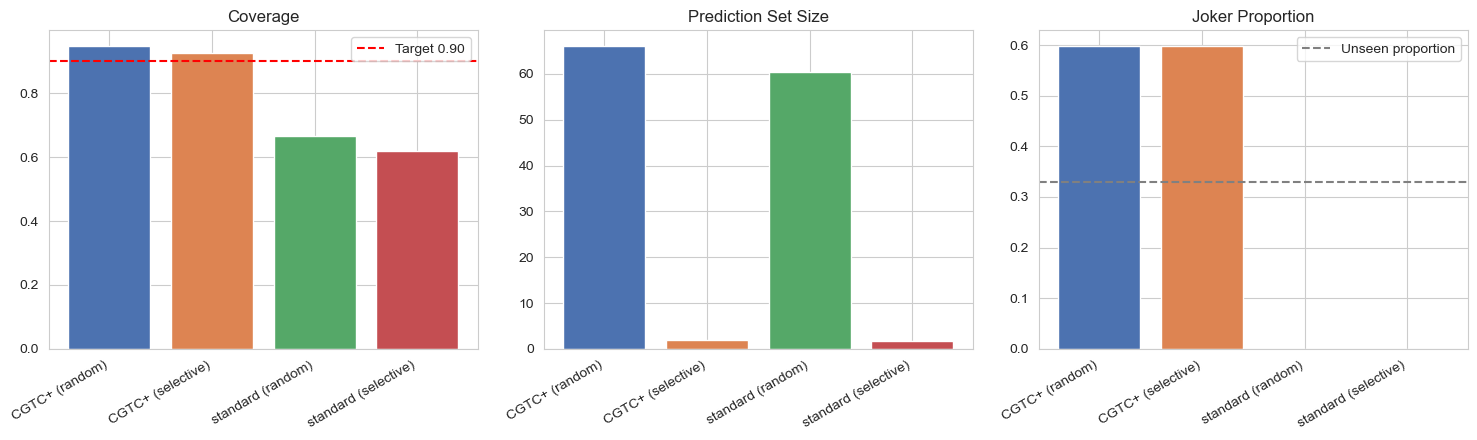

In [11]:
# Rows to plot: CGTC+ with the paper's XGT p-value, plus the standard benchmarks
plot_df = results_df[
    (results_df['pvalue_method'] == 'XGT') | (results_df['method'].str.startswith('standard'))
].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [('Coverage (?)', 'Coverage'),
          ('Size', 'Prediction Set Size'),
          ('Prop ?', 'Joker Proportion')]

for ax, (col, title) in zip(axes, panels):
    ax.bar(plot_df['method'], plot_df[col], color=sns.color_palette('deep', len(plot_df)))
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')

# Reference lines: nominal coverage and the realized unseen-label proportion
axes[0].axhline(1 - alpha_total, color='red', linestyle='--',
                label=f'Target {1 - alpha_total:.2f}')
axes[0].legend()
axes[2].axhline(prop_unseen, color='grey', linestyle='--', label='Unseen proportion')
axes[2].legend()

plt.tight_layout()
plt.show()

## Where to go next

- Full synthetic experiment over the paper's parameter grid: `synthetic_experiments/synthetic_experiment_dp_mm_plugin.py` (`submit_synthetic_experiment_dp_mm_plugin.sh` records the grid).
- Real-data (CelebA) version: `real_experiment/real_experiment_celeb_mm_plugin.py`.
- The original CGTC method (paper appendix): `CGTC_Demo.ipynb`.